<a href="https://colab.research.google.com/github/komiyaa/Titanic---Machine-Learning-from-Disaster/blob/main/Titanic_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy import median
import torch
import torch.nn as nn
import torch.nn.functional as F
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
class Model(nn.Module):
    def __init__(self, input_feature=11, h1=16, h2=8, output_feature=2):
      super().__init__()
      self.fc1 = nn.Linear(input_feature, h1)
      self.fc2 = nn.Linear(h1, h2)
      self.out = nn.Linear(h2, output_feature)

    def forward(self, x):
      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))
      x = self.out(x)
      return x

In [ ]:
torch.manual_seed(2)
model = Model()

In [ ]:
url1 = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
my_df = pd.read_csv(url1)
my_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:

# clean up data

# fuckass passengerID drop that shit
my_df = my_df.drop(["PassengerId"], axis=1)
my_df = my_df.drop(["Fare"], axis=1)

rare_titles = ["Lady", "the Countess","Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer"]

# determinate gender
my_df["Sex"] = my_df["Sex"].replace("female", 0.0) # female = 0.0
my_df["Sex"] = my_df["Sex"].replace("male", 1.0) # male = 1.0 (obviously)

# splitting names and only have their title
my_df["Name"] = my_df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())
my_df["Name"] = my_df["Name"].replace(rare_titles, "Rare")
my_df["Name"] = my_df["Name"].replace(["Mlle", "Ms"], "Miss")
my_df["Name"] = my_df["Name"].replace("Mme", "Mrs")

# encoding titles
title_mapping = {"Master": 0.0, "Miss": 1.0, "Mr": 2.0, "Mrs": 3.0, "Rare": 4.0}
my_df["Name"] = my_df["Name"].map(title_mapping)

# cleaning up ages
my_df["Age"] = my_df["Age"].fillna(my_df.groupby("Name")["Age"].transform("median")) # I calculated the median from each group to insert to replace NaN

# deleting tickets and creating a "Group" category
ticket_count = my_df["Ticket"].value_counts()
my_df["Group"] = (my_df["Ticket"].map(ticket_count) > 1).astype(float)
my_df = my_df.drop("Ticket", axis=1)

# detect if passanger has a cabin documented --> historical context: important people that had likely more survival chance
my_df["Cabins"] = my_df["Cabin"].notna().astype(float) # is Nan? -> 0.0, else 1.0
my_df = my_df.drop(columns=["Cabin"])

# embarked: split into 3 groups to not disrupt the data
my_df["Embarked"] = my_df["Embarked"].fillna("S")
my_df = pd.get_dummies(my_df, columns=["Embarked"], dtype=float) # how many variables are in the column? create new columns dependent of the variables: Labeling from 0.0 to 1.0
my_df

/tmp/ipykernel_607/1468224713.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df["Sex"] = my_df["Sex"].replace("male", 1.0) # male = 1.0 (obviously)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Group,Cabins,Embarked_C,Embarked_Q,Embarked_S
0,0,3,2.0,1.0,22.0,1,0,0.0,0.0,0.0,0.0,1.0
1,1,1,3.0,0.0,38.0,1,0,0.0,1.0,1.0,0.0,0.0
2,1,3,1.0,0.0,26.0,0,0,0.0,0.0,0.0,0.0,1.0
3,1,1,3.0,0.0,35.0,1,0,1.0,1.0,0.0,0.0,1.0
4,0,3,2.0,1.0,35.0,0,0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,4.0,1.0,27.0,0,0,0.0,0.0,0.0,0.0,1.0
887,1,1,1.0,0.0,19.0,0,0,0.0,1.0,0.0,0.0,1.0
888,0,3,1.0,0.0,21.0,1,2,1.0,0.0,0.0,0.0,1.0
889,1,1,2.0,1.0,26.0,0,0,0.0,1.0,1.0,0.0,0.0


In [ ]:
# train test split X, y
X = my_df.drop("Survived", axis=1)
y = my_df["Survived"]

In [ ]:
# convert to numpy arrays
X = X.values
y = y.values

In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [ ]:
# converting X features to float Tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [ ]:
# converting y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [ ]:
# measure loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# model train
epochs = 170
losses = []
for i in range(epochs):
  # forward
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train) # loss measure

  losses.append(loss.detach().numpy())

  if i % 50 == 0:
    print(f"Epoch: {i} --> loss {loss}")

  # backpropagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 --> loss 0.7435022592544556
Epoch: 50 --> loss 0.42784854769706726
Epoch: 100 --> loss 0.39430108666419983
Epoch: 150 --> loss 0.3779169023036957


Text(0.5, 0, 'epoch')

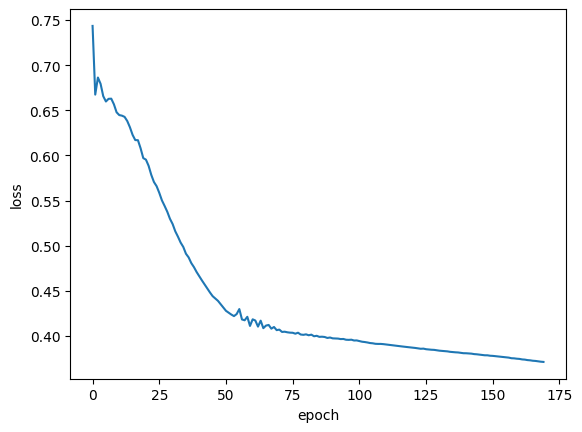

In [ ]:
# graph
plt.plot(range(epochs), losses)
plt.ylabel("loss")
plt.xlabel("epoch")

In [ ]:
# evaluate model on test data set
with torch.no_grad(): # turn off backpropagation
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test) # find the loss

In [ ]:
loss

tensor(0.3666)

In [ ]:

correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    # will tell if passengers survived or not
    print(f"{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}")

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f"correct {correct} \t {correct/len(X_test)}")

1.) tensor([0.7863, 1.2654]) 	 1 	 1
2.) tensor([ 1.4235, -0.9268]) 	 1 	 0
3.) tensor([ 1.6950, -1.3380]) 	 0 	 0
4.) tensor([ 2.2205, -0.3482]) 	 0 	 0
5.) tensor([1.4527, 0.3466]) 	 0 	 0
6.) tensor([1.6811, 0.1477]) 	 0 	 0
7.) tensor([ 1.4582, -0.8301]) 	 0 	 0
8.) tensor([-0.9184,  1.6166]) 	 1 	 1
9.) tensor([ 1.4138, -0.2991]) 	 0 	 0
10.) tensor([0.5603, 1.8700]) 	 1 	 1
11.) tensor([1.9840, 0.0555]) 	 0 	 0
12.) tensor([ 1.7116, -1.1612]) 	 0 	 0
13.) tensor([ 1.6950, -1.3380]) 	 0 	 0
14.) tensor([ 1.4582, -0.8301]) 	 0 	 0
15.) tensor([0.7816, 0.5200]) 	 0 	 0
16.) tensor([ 1.3654, -1.0774]) 	 0 	 0
17.) tensor([ 1.9662, -1.0919]) 	 0 	 0
18.) tensor([ 1.0410, -0.3953]) 	 0 	 0
19.) tensor([1.3300, 1.2664]) 	 0 	 0
20.) tensor([-10.2742,  11.3157]) 	 1 	 1
21.) tensor([ 1.1242, -0.3555]) 	 0 	 0
22.) tensor([1.3638, 1.0173]) 	 0 	 0
23.) tensor([ 1.3530, -1.0807]) 	 0 	 0
24.) tensor([0.5542, 0.1534]) 	 0 	 0
25.) tensor([ 1.4582, -0.8301]) 	 0 	 0
26.) tensor([ 1.0155, -0.

In [ ]:
test_df = pd.read_csv("Titanic_ml/test.csv")
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
# clean up data the seond time for test (almost copy-paste)

rare_titles = ["Lady", "the Countess","Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]

# determinate gender
test_df["Sex"] = test_df["Sex"].replace("female", 0.0) # female = 0.0
test_df["Sex"] = test_df["Sex"].replace("male", 1.0) # male = 1.0 (obviously)

# splitting names and only have their title
test_df["Name"] = test_df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())
test_df["Name"] = test_df["Name"].replace(rare_titles, "Rare")
test_df["Name"] = test_df["Name"].replace(["Mlle", "Ms"], "Miss")
test_df["Name"] = test_df["Name"].replace("Mme", "Mrs")

# encoding titles
title_mapping = {"Master": 0.0, "Miss": 1.0, "Mr": 2.0, "Mrs": 3.0, "Rare": 4.0}
test_df["Name"] = test_df["Name"].map(title_mapping)

# cleaning up ages
test_df["Age"] = test_df["Age"].fillna(test_df.groupby("Name")["Age"].transform("median")) # I calculated the median from each group to insert to replace NaN

# deleting tickets and creating a "Group" category
ticket_count = test_df["Ticket"].value_counts()
test_df["Group"] = (test_df["Ticket"].map(ticket_count) > 1).astype(float)
test_df = test_df.drop("Ticket", axis=1)

# detect if passanger has a cabin documented --> historical context: important people that had likely more survival chance
test_df["Cabins"] = test_df["Cabin"].notna().astype(float) # is Nan? -> 0.0, else 1.0
test_df = test_df.drop(columns=["Cabin"])

# embarked: split into 3 groups to not disrupt the data
test_df["Embarked"] = test_df["Embarked"].fillna("S")
test_df = pd.get_dummies(test_df, columns=["Embarked"], dtype=float) # how many variables are in the column? create new columns dependent of the variables: Labeling from 0.0 to 1.0
test_df

/tmp/ipykernel_607/1422930726.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df["Sex"] = test_df["Sex"].replace("male", 1.0) # male = 1.0 (obviously)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Group,Cabins,Embarked_C,Embarked_Q,Embarked_S
0,892,3,2.0,1.0,34.5,0,0,7.8292,0.0,0.0,0.0,1.0,0.0
1,893,3,3.0,0.0,47.0,1,0,7.0000,0.0,0.0,0.0,0.0,1.0
2,894,2,2.0,1.0,62.0,0,0,9.6875,0.0,0.0,0.0,1.0,0.0
3,895,3,2.0,1.0,27.0,0,0,8.6625,0.0,0.0,0.0,0.0,1.0
4,896,3,3.0,0.0,22.0,1,1,12.2875,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,2.0,1.0,28.5,0,0,8.0500,0.0,0.0,0.0,0.0,1.0
414,1306,1,4.0,0.0,39.0,0,0,108.9000,0.0,1.0,1.0,0.0,0.0
415,1307,3,2.0,1.0,38.5,0,0,7.2500,0.0,0.0,0.0,0.0,1.0
416,1308,3,2.0,1.0,28.5,0,0,8.0500,0.0,0.0,0.0,0.0,1.0


In [ ]:
passengerID = test_df["PassengerId"]

# dropping passangerId, fare
X_test_data = test_df.drop(["PassengerId", "Fare"], axis=1)

# filling in missing datasets with the median
X_test_data = X_test_data.fillna(X_test_data.median())

X_sub = torch.FloatTensor(X_test_data.values)
with torch.no_grad():
  prediction = model(X_sub).argmax(dim=1).numpy()

pd.DataFrame({"PassengerId": passengerID,
              "Survived": prediction}).to_csv("submission.csv", index=False)